# 05 - End-to-End Feature Engineering and Model Training

This notebook gives one place to inspect the full classification workflow for `transfer_success`.

It covers:
- loading the cleaned transfer dataset
- building leakage-safe feature splits
- checking class imbalance
- saving the preprocessing artifact
- training and tuning at least five models
- comparing validation and test results
- identifying the best model for the project report


In [1]:
from pathlib import Path
import json
import sys
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.features.build_features import build_feature_splits, infer_feature_columns, save_preprocessor_artifact
from src.models.transfer_success_modeling import run_model_selection

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)


In [2]:
DATASET_PATH = ROOT / "data" / "processed" / "transfer_modeling_dataset_clean.csv"
OUTPUT_DIR = ROOT / "models" / "transfer_success"
PREPROCESSOR_PATH = OUTPUT_DIR / "preprocessor_from_notebook.pkl"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATASET_PATH, OUTPUT_DIR

(WindowsPath('D:/DataScience/project/ScoutRadar/data/processed/transfer_modeling_dataset_clean.csv'),
 WindowsPath('D:/DataScience/project/ScoutRadar/models/transfer_success'))

## 1. Load the cleaned dataset

In [3]:
df = pd.read_csv(DATASET_PATH, parse_dates=["transfer_date"])

print(f"Shape: {df.shape}")
print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns)}")
print(f"Transfer date range: {df['transfer_date'].min().date()} to {df['transfer_date'].max().date()}")

df.head()

Shape: (6675, 102)
Rows: 6,675
Columns: 102
Transfer date range: 2018-07-01 to 2022-06-30


,transfer_key,player_id,player_full_name,transfer_date,transfer_season,source_club_id,source_club_name,source_competition_id,source_competition_name,destination_club_id,...,target_is_eligible,transfer_fee_missing_flag,is_free_transfer,transfer_fee_for_model,transfer_fee_log1p,pre_transfer_market_value_log1p,market_value_in_eur_log1p,target_end_market_value_log1p,highest_market_value_in_eur_log1p,player_current_market_value_log1p
0,7825_2018-07-01_6195_5,7825,Pepe Reina,2018-07-01,18/19,6195,SSC Napoli,IT1,serie-a,5,...,True,0,1,0.0,0.000000,13.815512,13.815512,13.384729,16.906553,13.304687
1,11111_2018-07-01_29_1050,11111,Ramiro Funes Mori,2018-07-01,18/19,29,Everton,GB1,premier-league,1050,...,True,0,0,9000000.0,16.012735,16.118096,16.118096,15.384127,16.300417,11.225257
2,22141_2018-07-01_1025_12,22141,Antonio Mirante,2018-07-01,18/19,1025,Bologna,IT1,serie-a,12,...,True,0,0,4000000.0,15.201805,13.815512,13.815512,13.384729,15.607270,11.512935
3,27490_2018-07-01_1147_826,27490,Jean-Louis Leca,2018-07-01,18/19,1147,AC Ajaccio,FR1,ligue-1,826,...,True,0,0,300000.0,12.611541,13.815512,13.815512,13.592368,14.077876,12.206078
4,28140_2018-07-01_989_415,28140,Max Gradel,2018-07-01,18/19,989,Bournemouth,GB1,premier-league,415,...,True,0,0,2000000.0,14.508658,15.761421,15.761421,15.201805,16.012735,13.527830


## 2. Inspect the target and class imbalance

transfer_success
0    5527
1    1148
Name: count, dtype: int64
Positive class rate: 17.20%
Negative to positive ratio: 4.81:1


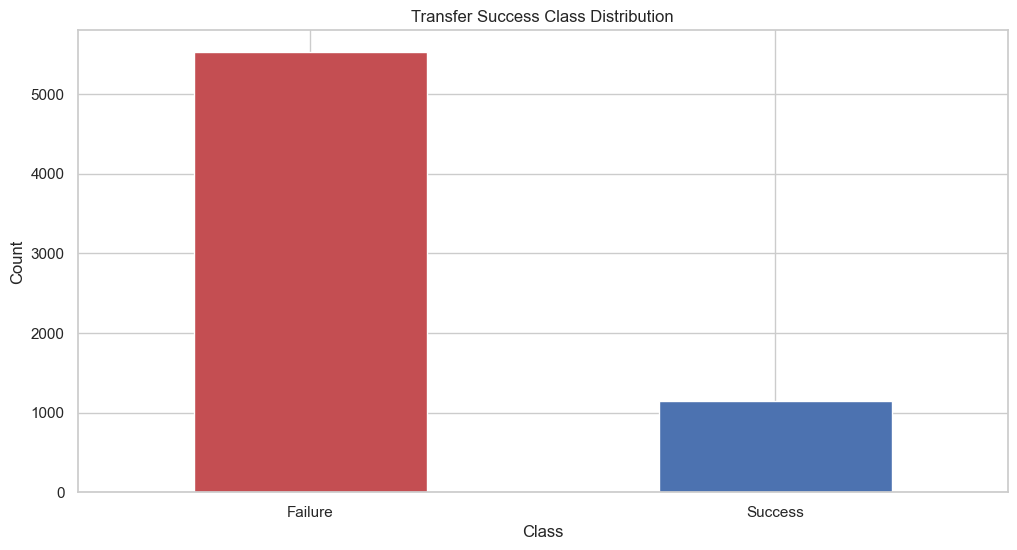

In [4]:
target_counts = df["transfer_success"].value_counts().sort_index()
target_share = df["transfer_success"].mean()

print(target_counts)
print(f"Positive class rate: {target_share:.2%}")
print(f"Negative to positive ratio: {(1 - target_share) / target_share:.2f}:1")

ax = target_counts.rename({0: "Failure", 1: "Success"}).plot(kind="bar", color=["#c44e52", "#4c72b0"])
ax.set_title("Transfer Success Class Distribution")
ax.set_xlabel("Class")
ax.set_ylabel("Count")
plt.xticks(rotation=0)
plt.show()

## 3. Build feature engineering outputs

In [5]:
payload = build_feature_splits(df, target_col="transfer_success")
feature_columns = payload["feature_columns"]
feature_names = payload["feature_names"]

save_preprocessor_artifact(payload, PREPROCESSOR_PATH)

print(f"Selected raw feature columns: {len(feature_columns)}")
print(f"Transformed model features: {len(feature_names)}")
print(f"Numeric input columns: {len(payload['numeric_columns'])}")
print(f"Categorical input columns: {len(payload['categorical_columns'])}")
print(f"Saved preprocessor artifact to: {PREPROCESSOR_PATH}")

Selected raw feature columns: 57
Transformed model features: 220
Numeric input columns: 50
Categorical input columns: 7
Saved preprocessor artifact to: D:\DataScience\project\ScoutRadar\models\transfer_success\preprocessor_from_notebook.pkl


In [6]:
payload["split_summary"]

,split,rows,start_date,end_date
0,train,4672,2018-07-01,2021-06-30
1,val,1001,2021-06-30,2021-08-31
2,test,1002,2021-08-31,2022-06-30


In [7]:
pd.Series(feature_columns, name="raw_feature_column").to_frame().head(25)

,raw_feature_column
0,source_competition_id
1,destination_competition_id
2,age_at_transfer
3,position
4,sub_position
5,foot
6,height_in_cm
7,country_of_citizenship
8,pre_transfer_market_value_source
9,market_value_180d_prior


In [8]:
pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "rows": [len(payload["X_train"]), len(payload["X_val"]), len(payload["X_test"])],
        "columns": [payload["X_train"].shape[1], payload["X_val"].shape[1], payload["X_test"].shape[1]],
        "positive_rate": [
            payload["y_train"].mean(),
            payload["y_val"].mean(),
            payload["y_test"].mean(),
        ],
    }
)

,split,rows,columns,positive_rate
0,train,4672,220,0.181293
1,validation,1001,220,0.204795
2,test,1002,220,0.095808


## 4. Train, tune, and evaluate models

In [9]:
result = run_model_selection(
    dataset_path=DATASET_PATH,
    output_dir=OUTPUT_DIR,
    experiment_name="Transfer Success Prediction",
)

comparison = result["results"].copy()
comparison

2026/05/01 03:14:09 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/01 03:14:17 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/01 03:14:42 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mec

,model_name,balance_strategy,cv_best_f1,decision_threshold,val_f1,val_pr_auc,val_recall,test_f1,test_pr_auc,test_recall,test_precision,test_false_positive_fee_exposure,mlflow_run_id
0,XGBoost,scale_pos_weight,0.509739,0.50,0.574669,0.580197,0.741463,0.419355,0.419602,0.677083,0.303738,343830000.0,ef6193fd22ad40b0b29991711da8dfdd
1,Random Forest,class_weight,0.438507,0.40,0.543568,0.515430,0.639024,0.388186,0.382054,0.479167,0.326241,396960000.0,e0db1d694ca34e75bb8206559218910e
2,Extra Trees,class_weight,0.476276,0.40,0.506518,0.501202,0.663415,0.401575,0.380361,0.531250,0.322785,482219000.0,600bba75be8d401889261cb9bda35f54
3,Linear SVM,class_weight,0.456808,0.55,0.504464,0.487693,0.551220,0.360976,0.363275,0.385417,0.339450,238100000.0,b0605ba688d54ff8bc7ef94009638f54
4,Logistic Regression + SMOTE,smote_train_only,0.472889,0.55,0.490272,0.469018,0.614634,0.365019,0.334330,0.500000,0.287425,258130000.0,3699b4649fe144d095bb743e66850f69
5,Dummy Baseline,none,0.000000,0.20,0.000000,0.602398,0.000000,0.000000,0.547904,0.000000,0.000000,0.0,9b55a391894f43cc9e47e7ede803b808


In [10]:
best_model = result["best_model"]

print("Best model:", best_model["model_name"])
print("Balance strategy:", best_model["balance_strategy"])
print("Best parameters:", best_model["best_params"])
print("Decision threshold:", best_model["decision_threshold"])
print("Validation F1:", round(best_model["val_metrics"]["f1"], 4))
print("Test F1:", round(best_model["test_metrics"]["f1"], 4))
print("Test recall:", round(best_model["test_metrics"]["recall"], 4))
print("Test precision:", round(best_model["test_metrics"]["precision"], 4))
print("MLflow run id:", best_model["run_id"])

Best model: XGBoost
Balance strategy: scale_pos_weight
Best parameters: {'learning_rate': 0.03, 'max_depth': 4, 'n_estimators': 350}
Decision threshold: 0.5
Validation F1: 0.5747
Test F1: 0.4194
Test recall: 0.6771
Test precision: 0.3037
MLflow run id: ef6193fd22ad40b0b29991711da8dfdd


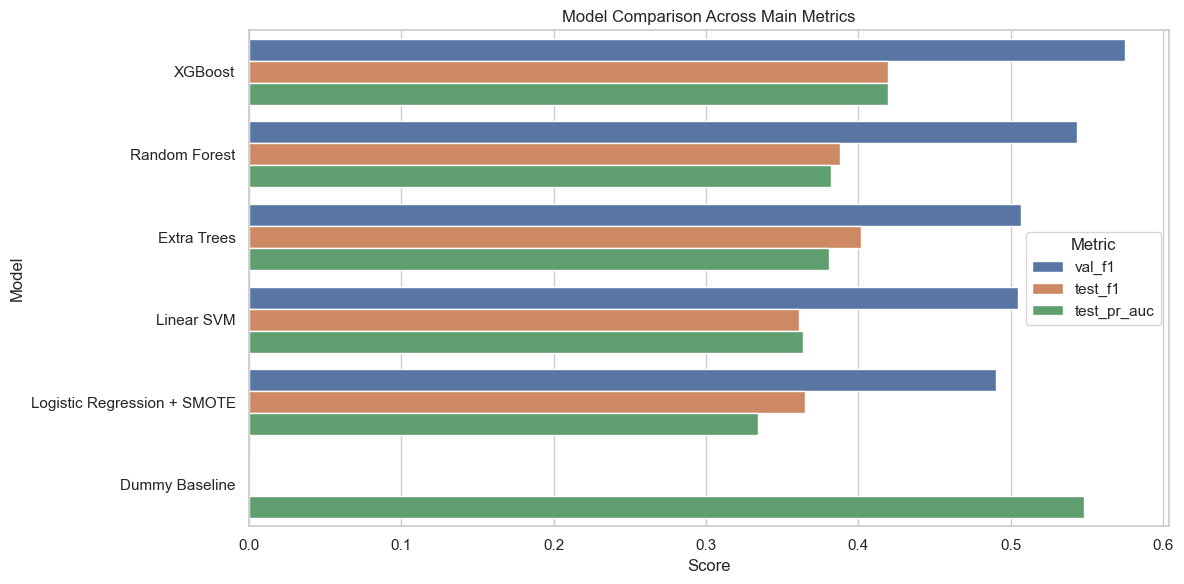

In [11]:
plot_df = comparison[["model_name", "val_f1", "test_f1", "test_pr_auc"]].melt(
    id_vars="model_name",
    var_name="metric",
    value_name="score",
)

ax = sns.barplot(data=plot_df, x="score", y="model_name", hue="metric")
ax.set_title("Model Comparison Across Main Metrics")
ax.set_xlabel("Score")
ax.set_ylabel("Model")
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

In [12]:
print("Saved files:")
for path in sorted(OUTPUT_DIR.glob("*")):
    print("-", path.name)

Saved files:
- best_model.json
- dummy_baseline_summary.json
- extra_trees_summary.json
- feature_payload.joblib
- linear_svm_summary.json
- logistic_regression_plus_smote_summary.json
- model_comparison.csv
- preprocessor.pkl
- preprocessor_from_notebook.pkl
- random_forest_summary.json
- split_summary.csv
- transfer_preprocessor.pkl
- xgboost_summary.json


In [13]:
best_model_path = OUTPUT_DIR / "best_model.json"
json.loads(best_model_path.read_text(encoding="utf-8"))

{'model_name': 'XGBoost',
 'balance_strategy': 'scale_pos_weight',
 'best_params': {'learning_rate': 0.03, 'max_depth': 4, 'n_estimators': 350},
 'cv_best_f1': 0.5097388322657327,
 'decision_threshold': 0.5,
 'train_metrics': {'accuracy': 0.8705051369863014,
  'precision': 0.5911144578313253,
  'recall': 0.9268004722550177,
  'f1': 0.7218390804597701,
  'roc_auc': 0.9604707117006583,
  'pr_auc': 0.8417365841309107,
  'recommendation_rate': 0.2842465753424658,
  'successful_recommendation_rate': 0.5911144578313253,
  'captured_success_fee_rate': 0.9994520357404171,
  'false_positive_fee_exposure': 3116650000.0,
  'missed_success_fee': 3451000.0},
 'val_metrics': {'accuracy': 0.7752247752247752,
  'precision': 0.4691358024691358,
  'recall': 0.7414634146341463,
  'f1': 0.5746691871455577,
  'roc_auc': 0.8469175144012746,
  'pr_auc': 0.5801970813121144,
  'recommendation_rate': 0.32367632367632365,
  'successful_recommendation_rate': 0.4691358024691358,
  'captured_success_fee_rate': 0.96